# **AESO Short-Term Load & Pool Price Forecasting**

**Final portfolio project scope**

This notebook revisits and expands the original AESO load-forecasting project into a more complete short-term market analytics workflow:

1. Clean and validate AESO hourly data, including repeated daylight-saving-time hours.
2. Rebuild the load forecast using leakage-safe historical features.
3. Compare Linear Regression and XGBoost for hourly load.
4. Build an hourly pool-price forecast using only information available before the forecast hour.
5. Compare the price model with simple persistence baselines.
6. Add a high-price probability model as a practical risk signal.
7. Diagnose forecast errors and model drivers.
8. Export reusable model outputs and generate a **Streamlit portfolio dashboard** with plain-language labels and a viewer glossary.

The purpose is not to claim that electricity prices are perfectly predictable. Instead, the project asks: **what can historical market data predict reliably, where does it struggle, and what additional information would improve the forecast?**

This version also documents how the project evolved. The original load-only analysis was a useful first iteration; the final version makes the forecasting setup more realistic by ensuring that each prediction uses only information that would have been known before the forecast hour.


## Forecasting design choices

The forecasting models are designed to resemble a real next-hour forecasting workflow. For hour **t**, they may use calendar information known in advance and values observed **before hour t**, but not realized values from the hour being predicted.

That means same-hour pool price is excluded from the load forecast, same-hour load is excluded from the price forecast, rolling statistics are calculated after `shift(1)`, and evaluation uses a later held-out period instead of a random split.

These choices matter because a model can appear artificially accurate if it is allowed to use information that would not exist at forecast time. The goal here is to measure performance under a more realistic information set.


## **Notebook Setup**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from xgboost import XGBRegressor, XGBClassifier

import plotly.graph_objects as go
import plotly.io as pio

RANDOM_STATE = 42
PRICE_SPIKE_THRESHOLD = 100.0  # CAD/MWh; change if you want a different "high-price" definition

pd.set_option("display.max_columns", 100)

## **Loading the AESO data**



In [ ]:
from pathlib import Path

# Main project folder in Google Drive
PROJECT_DIR = Path("/content/drive/MyDrive/Private projects/AESO Data")

# Input and output folders
INPUT_DIR = PROJECT_DIR / "input"
OUTPUT_DIR = PROJECT_DIR / "output"

# Create the folders if they don't already exist
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# AESO input file
DATA_PATH = INPUT_DIR / "HistoricalPoolPriceReportServlet_04-30-2024_to_04-15-2026 - .csv"

print("Project folder:", PROJECT_DIR)
print("Input folder:", INPUT_DIR)
print("Output folder:", OUTPUT_DIR)
print("AESO data found:", DATA_PATH.exists())

Project folder: /content/drive/MyDrive/Private projects/AESO Data
Input folder: /content/drive/MyDrive/Private projects/AESO Data/input
Output folder: /content/drive/MyDrive/Private projects/AESO Data/output
AESO data found: True


## **Repair the AESO export and clean data types**

In [ ]:
df_raw = pd.read_csv(DATA_PATH, header=3)
print("Raw data shape:", df_raw.shape)
df_raw.head()

Raw data shape: (17185, 4)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Date (HE),Price ($),30Ravg ($),AIL Demand (MW)
1,04/30/2024 01,64.5,68.48,8962
2,04/30/2024 02,101.8,68.56,8893
3,04/30/2024 03,33.68,68.54,8879
4,04/30/2024 04,33.63,68.52,8905


In [ ]:
df = df_raw.copy()

# The first row contains the actual column names in this AESO export
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

df = df.rename(columns={
    "Date (HE)": "date_he",
    "Price ($)": "pool_price",
    "30Ravg ($)": "price_30d_avg",
    "AIL Demand (MW)": "load",})

# Split AESO date/hour-ending representation
df[["date", "he_raw"]] = df["date_he"].astype(str).str.split(" ", expand=True)

# Preserve repeated DST hour, e.g. 02*
df["he"] = df["he_raw"].str.extract(r"(\d+)").astype("Int64")
df["is_dst_repeat"] = df["he_raw"].str.contains(r"\*", na=False)

# Convert types
df["date"] = pd.to_datetime(df["date"], errors="coerce")
for col in ["load", "pool_price", "price_30d_avg"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["date", "he", "load", "pool_price"]).copy()
df["he"] = df["he"].astype(int)

# True event order: regular repeated hour first, then starred repeated hour
df = df.sort_values(["date", "he", "is_dst_repeat"]).reset_index(drop=True)

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17184 entries, 0 to 17183
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date_he        17184 non-null  object        
 1   pool_price     17184 non-null  float64       
 2   price_30d_avg  17184 non-null  float64       
 3   load           17184 non-null  int64         
 4   date           17184 non-null  datetime64[ns]
 5   he_raw         17184 non-null  object        
 6   he             17184 non-null  int64         
 7   is_dst_repeat  17184 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 956.7+ KB
None


,date_he,pool_price,price_30d_avg,load,date,he_raw,he,is_dst_repeat
0,04/30/2024 01,64.50,68.48,8962,2024-04-30,01,1,False
1,04/30/2024 02,101.80,68.56,8893,2024-04-30,02,2,False
2,04/30/2024 03,33.68,68.54,8879,2024-04-30,03,3,False
3,04/30/2024 04,33.63,68.52,8905,2024-04-30,04,4,False
4,04/30/2024 05,33.36,68.50,8944,2024-04-30,05,5,False


## **Data-quality and DST checks**

AESO reports electricity data using local Alberta time. When daylight saving time changes, the clock either moves forward or backward. That can create an hour that appears to be missing or repeated, which can cause problems when arranging the data in a continuous timeline.

To deal with this, the workbook uses two versions of time for different purposes:

* A sequential timestamp keeps every observation in the correct order so the model knows which hour comes before and after another.
* The original AESO date and hour-ending values are used to create calendar features such as hour of day, day of week, and month.

In [ ]:
# Unique sequential index for machine-learning alignment
start_ts = df.loc[0, "date"] + pd.Timedelta(hours=int(df.loc[0, "he"]) - 1)
df["model_timestamp"] = start_ts + pd.to_timedelta(np.arange(len(df)), unit="h")

# Local clock representation for interpretation/dashboard labels
df["local_hour_start"] = df["he"] - 1
df["local_datetime_naive"] = (
    df["date"] + pd.to_timedelta(df["local_hour_start"], unit="h"))

print("Rows:", len(df))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Repeated DST rows:", int(df["is_dst_repeat"].sum()))
print("Missing load:", int(df["load"].isna().sum()))
print("Missing price:", int(df["pool_price"].isna().sum()))
print("Duplicate sequential timestamps:", int(df["model_timestamp"].duplicated().sum()))

df.loc[df["is_dst_repeat"], ["date_he", "date", "he_raw", "model_timestamp"]].head(10)

Rows: 17184
Date range: 2024-04-30 to 2026-04-15
Repeated DST rows: 2
Missing load: 0
Missing price: 0
Duplicate sequential timestamps: 0


,date_he,date,he_raw,model_timestamp
4490,11/03/2024 02*,2024-11-03,02*,2024-11-03 02:00:00
13226,11/02/2025 02*,2025-11-02,02*,2025-11-02 02:00:00


**Notes**
* The dataset contains 17,184 hourly observations with no missing load or pool-price values.

* Two repeated hours were identified during the fall daylight saving time changes in 2024 and 2025, which is expected in Alberta local-time data.

* The sequential model timestamp successfully preserves the order of all observations without creating duplicate timestamps. This is important for time-series modelling because lag and rolling features depend on the correct sequence of observations, while the original AESO time fields can still be used to represent the actual market hour.



##  **Leakage-safe feature engineering**

The key rule is simple: a feature for hour **t** may use information from hours **before t**, plus calendar information already known in advance.

For rolling averages and other rolling statistics, shift(1) ensures that the current hour is excluded from the calculation. This prevents data leakage and keeps the forecasts realistic.

In [ ]:
work = df.copy()

# Calendar features from original AESO local clock
work["hour"] = work["local_hour_start"]
work["dayofweek"] = work["date"].dt.dayofweek
work["month"] = work["date"].dt.month
work["day"] = work["date"].dt.day
work["is_weekend"] = (work["dayofweek"] >= 5).astype(int)

# Cyclical encodings let models understand that hour 23 is close to hour 0
work["hour_sin"] = np.sin(2 * np.pi * work["hour"] / 24)
work["hour_cos"] = np.cos(2 * np.pi * work["hour"] / 24)
work["dow_sin"] = np.sin(2 * np.pi * work["dayofweek"] / 7)
work["dow_cos"] = np.cos(2 * np.pi * work["dayofweek"] / 7)
work["month_sin"] = np.sin(2 * np.pi * (work["month"] - 1) / 12)
work["month_cos"] = np.cos(2 * np.pi * (work["month"] - 1) / 12)

# Load lags
for lag in [1, 2, 24, 48, 168]:
    work[f"load_lag_{lag}"] = work["load"].shift(lag)

# Leakage-safe load rolling history
for window in [6, 24, 168]:
    shifted_load = work["load"].shift(1)
    work[f"load_roll_mean_{window}"] = shifted_load.rolling(window).mean()
    work[f"load_roll_std_{window}"] = shifted_load.rolling(window).std()

# Price lags for the later price model
for lag in [1, 2, 3, 24, 48, 168]:
    work[f"price_lag_{lag}"] = work["pool_price"].shift(lag)

# Leakage-safe price rolling history
for window in [6, 24, 168, 720]:
    shifted_price = work["pool_price"].shift(1)
    work[f"price_roll_mean_{window}"] = shifted_price.rolling(window).mean()
    work[f"price_roll_std_{window}"] = shifted_price.rolling(window).std()
    work[f"price_roll_max_{window}"] = shifted_price.rolling(window).max()

# Recent price movement/regime features
work["price_change_1h"] = work["price_lag_1"] - work["price_lag_2"]
work["load_change_1h"] = work["load_lag_1"] - work["load_lag_2"]

# High-price target used later for the risk classifier
work["is_high_price"] = (work["pool_price"] >= PRICE_SPIKE_THRESHOLD).astype(int)

work.head()

,date_he,pool_price,price_30d_avg,load,date,he_raw,he,is_dst_repeat,model_timestamp,local_hour_start,local_datetime_naive,hour,dayofweek,month,day,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,load_lag_1,load_lag_2,load_lag_24,load_lag_48,load_lag_168,load_roll_mean_6,load_roll_std_6,load_roll_mean_24,load_roll_std_24,load_roll_mean_168,load_roll_std_168,price_lag_1,price_lag_2,price_lag_3,price_lag_24,price_lag_48,price_lag_168,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_mean_24,price_roll_std_24,price_roll_max_24,price_roll_mean_168,price_roll_std_168,price_roll_max_168,price_roll_mean_720,price_roll_std_720,price_roll_max_720,price_change_1h,load_change_1h,is_high_price
0,04/30/2024 01,64.50,68.48,8962,2024-04-30,01,1,False,2024-04-30 00:00:00,0,2024-04-30 00:00:00,0,1,4,30,0,0.000000,1.000000,0.781831,0.62349,1.0,6.123234e-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,04/30/2024 02,101.80,68.56,8893,2024-04-30,02,2,False,2024-04-30 01:00:00,1,2024-04-30 01:00:00,1,1,4,30,0,0.258819,0.965926,0.781831,0.62349,1.0,6.123234e-17,8962.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,04/30/2024 03,33.68,68.54,8879,2024-04-30,03,3,False,2024-04-30 02:00:00,2,2024-04-30 02:00:00,2,1,4,30,0,0.500000,0.866025,0.781831,0.62349,1.0,6.123234e-17,8893.0,8962.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.80,64.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.30,-69.0,0
3,04/30/2024 04,33.63,68.52,8905,2024-04-30,04,4,False,2024-04-30 03:00:00,3,2024-04-30 03:00:00,3,1,4,30,0,0.707107,0.707107,0.781831,0.62349,1.0,6.123234e-17,8879.0,8893.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.68,101.80,64.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-68.12,-14.0,0
4,04/30/2024 05,33.36,68.50,8944,2024-04-30,05,5,False,2024-04-30 04:00:00,4,2024-04-30 04:00:00,4,1,4,30,0,0.866025,0.500000,0.781831,0.62349,1.0,6.123234e-17,8905.0,8879.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.63,33.68,101.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.05,26.0,0


**Notes**

* This step creates the features used by the forecasting models.

* Calendar variables capture hourly, daily, weekly, and seasonal patterns, while lag features show what load and price were in previous hours, days, and weeks.

* Rolling statistics summarize recent averages, variability, and price extremes, and change features capture recent market movement. All historical features use only past information to avoid data leakage.

* The missing values at the beginning are expected because longer lag and rolling features require enough historical observations before they can be calculated.

* A high-price indicator is also created for the later price-risk classification model.

## **Chronological train/test split**

The chronological split trains the models on earlier data and tests them on a later, unseen period, which better reflects real-world forecasting than a random split.

The same cutoff date is used for both the load and price models so their performance is evaluated over the same future market conditions

In [ ]:
def chronological_split(data, feature_cols, target_col, train_fraction=0.80):
    model_df = data.dropna(subset=feature_cols + [target_col]).copy()
    split_idx = int(len(model_df) * train_fraction)

    train = model_df.iloc[:split_idx].copy()
    test = model_df.iloc[split_idx:].copy()

    X_train = train[feature_cols]
    y_train = train[target_col]
    X_test = test[feature_cols]
    y_test = test[target_col]

    return model_df, train, test, X_train, X_test, y_train, y_test


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),}

# **Part A - Hourly Load Forecasting**

The load model uses calendar structure plus lagged/rolling load only.

In [ ]:
calendar_features = [
    "hour", "dayofweek", "month", "day", "is_weekend", "is_dst_repeat",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",]

load_history_features = [
    "load_lag_1", "load_lag_2", "load_lag_24", "load_lag_48", "load_lag_168",
    "load_roll_mean_6", "load_roll_std_6",
    "load_roll_mean_24", "load_roll_std_24",
    "load_roll_mean_168", "load_roll_std_168",
    "load_change_1h",]

load_features = calendar_features + load_history_features

(  load_model_df,
    load_train,
    load_test,
    X_train_load,
    X_test_load,
    y_train_load,
    y_test_load,
   ) = chronological_split(work, load_features, "load", train_fraction=0.80)

print("Load training rows:", len(load_train))
print("Load test rows:", len(load_test))
print("Load test period:", load_test["date"].min().date(), "to", load_test["date"].max().date())

Load training rows: 13612
Load test rows: 3404
Load test period: 2025-11-25 to 2026-04-15


## **Notes**

* After creating the load features, 17,016 usable observations remain.

* The first 80% (13,612 rows) are used for training and the most recent 20% (3,404 rows) are reserved for testing, covering November 25, 2025 to April 15, 2026.

* This keeps the data in chronological order and tests the model on a continuous future period it has not seen during training.

In [ ]:
# Linear Regression baseline
lr_load = LinearRegression()
lr_load.fit(X_train_load, y_train_load)
pred_load_lr = lr_load.predict(X_test_load)

# XGBoost load model
xgb_load = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,)

xgb_load.fit(X_train_load, y_train_load)
pred_load_xgb = xgb_load.predict(X_test_load)

load_metrics = pd.DataFrame([
    {"Model": "Linear Regression", **regression_metrics(y_test_load, pred_load_lr)},
    {"Model": "XGBoost", **regression_metrics(y_test_load, pred_load_xgb)},
])

load_metrics

,Model,MAE,RMSE,R2
0,Linear Regression,60.417053,79.862594,0.983005
1,XGBoost,54.931961,85.120385,0.980693


## **Notes**

* Both models performed very well, explaining about 98% of the variation in load.
* XGBoost had the lower average error (MAE of about 55 MW versus 60 MW), meaning it was generally more accurate hour to hour. However, Linear Regression had the lower RMSE and slightly higher R², suggesting it handled the larger forecasting errors better.
* This shows that a more complex model is not automatically better on every measure and highlights the value of comparing against a simple baseline.

In [ ]:
# Improvement relative to Linear Regression
lr_row = load_metrics.set_index("Model").loc["Linear Regression"]
xgb_row = load_metrics.set_index("Model").loc["XGBoost"]

print(f"MAE improvement:  {(1 - xgb_row['MAE']/lr_row['MAE'])*100:.1f}%")
print(f"RMSE improvement: {(1 - xgb_row['RMSE']/lr_row['RMSE'])*100:.1f}%")
print(f"R² change:        {xgb_row['R2'] - lr_row['R2']:+.3f}")

MAE improvement:  9.1%
RMSE improvement: -6.6%
R² change:        -0.002


# **Notes**

* MAE: +9.1% improvement — XGBoost made smaller errors during a typical hour.
* RMSE: -6.6% improvement — this wasn’t actually an improvement. XGBoost’s RMSE was about 6.6% worse, suggesting it had some larger errors that hurt its performance.
* R²: -0.002 — essentially very little difference, although Linear Regression was slightly better.

So XGBoost didn’t clearly dominate Linear Regression.

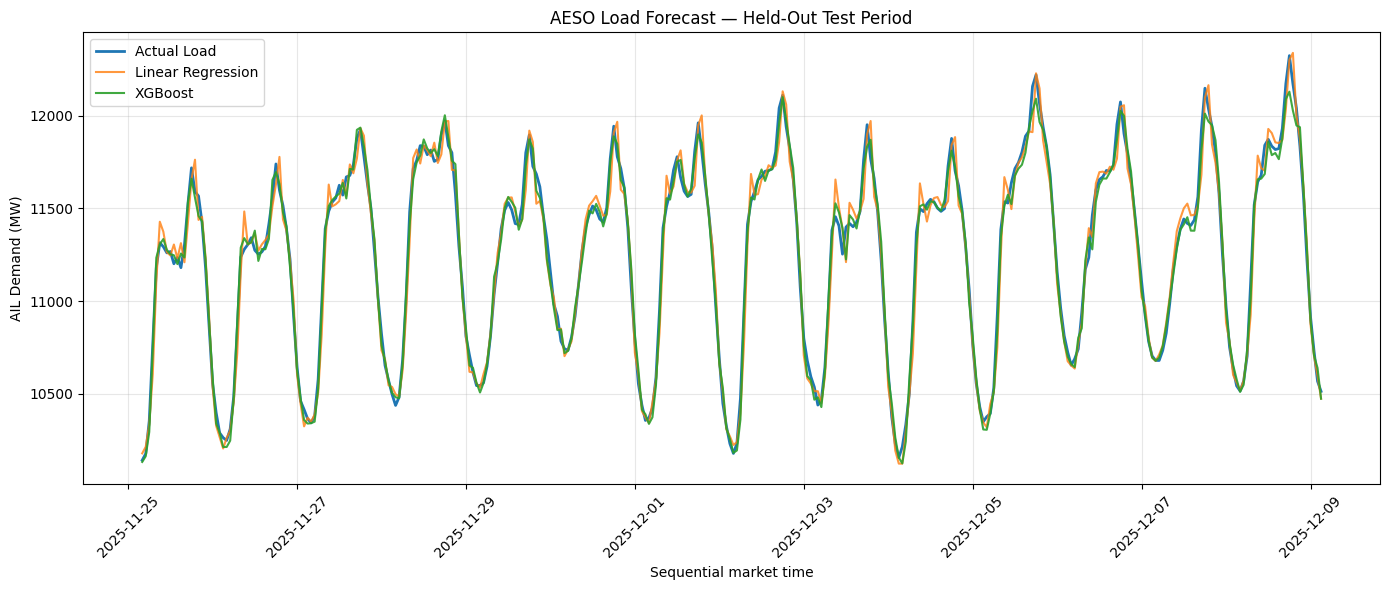

In [ ]:
# Plot a readable window from the test data
n_plot = min(336, len(load_test))  # roughly two weeks

plt.figure(figsize=(14, 6))
plt.plot(load_test["model_timestamp"].iloc[:n_plot], y_test_load.iloc[:n_plot],
         label="Actual Load", linewidth=2)
plt.plot(load_test["model_timestamp"].iloc[:n_plot], pred_load_lr[:n_plot],
         label="Linear Regression", alpha=0.8)
plt.plot(load_test["model_timestamp"].iloc[:n_plot], pred_load_xgb[:n_plot],
         label="XGBoost", alpha=0.9)

plt.title("AESO Load Forecast — Held-Out Test Period")
plt.xlabel("Sequential market time")
plt.ylabel("AIL Demand (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Notes**

* Both Linear Regression and XGBoost closely follow the actual load and capture the strong daily demand pattern.
* The small visual difference between the models supports the earlier metrics: both perform very well, with XGBoost improving typical hourly errors but occasionally making larger misses.
* The results also show that the simpler Linear Regression model is already very effective at capturing Alberta’s regular load patterns.

## **Load-model feature importance**

Feature importance shows what information XGBoost found most useful for making its load predictions, but it does not prove that those variables caused electricity demand to change.

,feature,importance
0,load_lag_1,0.852550
1,load_lag_24,0.069848
2,hour_cos,0.025822
3,load_change_1h,0.015122
4,load_lag_168,0.005805
5,load_lag_2,0.005559
6,hour,0.004845
7,hour_sin,0.004110
8,load_roll_mean_24,0.003876
9,is_weekend,0.002677


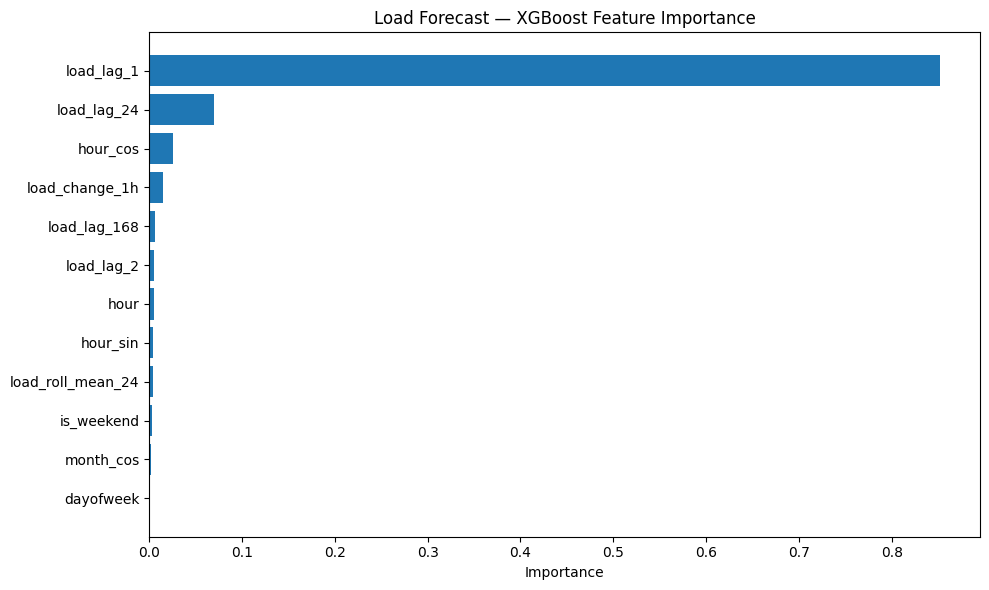

In [ ]:
load_importance = (
    pd.DataFrame({
        "feature": load_features,
        "importance": xgb_load.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True))

display(load_importance.head(15))

plt.figure(figsize=(10, 6))
top = load_importance.head(12).sort_values("importance")
plt.barh(top["feature"], top["importance"])
plt.title("Load Forecast — XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# **Notes**

* load_lag_1 has an importance of 0.853, or about 85% of the total feature importance.
  * That means the model relies very heavily on what electricity demand was one hour earlier when predicting the next hour
  * It also helps explain why Linear Regression performed so well earlier. The load forecast is strongly driven by recent historical load, so you don’t necessarily need extremely complicated relationships to get a good prediction.

* The second most important variable is load_lag_24 — about 7%
  *  That’s the load 24 hours earlier, or approximately the same time the previous day. This tells us the model also finds the daily repeating pattern useful.

After that, importance falls dramatically.

* Time-of-day and recent load movement provide additional information, while weekly, monthly, and other calendar features contribute much less.

* This suggests that short-term AESO load is highly persistent and follows strong daily patterns.

* The dominance of the one-hour lag also makes a simple persistence forecast a useful additional baseline for evaluating whether the machine-learning models provide meaningful improvement.

## **Load error analysis**

If errors grow during specific hours or months, that points to missing drivers such as temperature, holidays, outages, or unusual industrial demand.

In [ ]:
load_results = load_test[
    ["model_timestamp", "local_datetime_naive", "date", "hour", "dayofweek", "month", "load"]
].copy()
load_results["pred_load_lr"] = pred_load_lr
load_results["pred_load_xgb"] = pred_load_xgb
load_results["error_xgb"] = load_results["load"] - load_results["pred_load_xgb"]
load_results["abs_error_xgb"] = load_results["error_xgb"].abs()

load_error_by_hour = (
    load_results.groupby("hour", as_index=False)["abs_error_xgb"].mean()
    .rename(columns={"abs_error_xgb": "MAE_MW"}))

load_error_by_month = (
    load_results.groupby("month", as_index=False)["abs_error_xgb"].mean()
    .rename(columns={"abs_error_xgb": "MAE_MW"}))

display(load_error_by_hour)
display(load_error_by_month)

,hour,MAE_MW
0,0,34.032968
1,1,30.908092
2,2,34.105690
3,3,32.630254
4,4,35.765948
5,5,39.049089
6,6,45.002345
7,7,67.609258
8,8,56.267963
9,9,57.978247


,month,MAE_MW
0,1,42.953727
1,2,42.746720
2,3,49.658507
3,4,43.874224
4,11,39.445984
5,12,91.467936


# **Notes**

* The error analysis shows that XGBoost performs best during the more stable overnight hours, while errors increase during daytime demand changes and are highest around 5–6 PM.

* December 2025 also stands out, with a much higher average error than the other months in the test period. This suggests that historical load patterns alone may not capture unusual conditions such as weather, holidays, or changes in industrial demand.

* Since the test period contains only one winter and partial November and April data, the monthly results should be treated as observations from this test period rather than a general seasonal conclusion.

# **Part B — Hourly Pool Price Forecasting**

Pool price prediction is a harder problem than load prediction.

Electricity load is relatively predictable because people and businesses tend to follow repeating daily and weekly patterns. Pool prices are much more unpredictable because they can suddenly spike or fall when something changes in the electricity market.

For example, prices could suddenly rise because a power plant goes offline, electricity supply becomes tight, wind generation drops, imports decrease, or generators change their offers. The current dataset doesn’t contain most of this information

Instead of trying to perfectly predict the next hour AESO pool price this model asks a narrower question:

> **How much of the next hour price can we reasonably predict from - recent price behavior, recent demand, and predictable calendar patterns?**

A lower R² than the load model is therefore expected and helps show the limitations of forecasting price from historical patterns alone.

In [ ]:
price_history_features = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "price_lag_24", "price_lag_48", "price_lag_168",
    "price_roll_mean_6", "price_roll_std_6", "price_roll_max_6",
    "price_roll_mean_24", "price_roll_std_24", "price_roll_max_24",
    "price_roll_mean_168", "price_roll_std_168", "price_roll_max_168",
    "price_roll_mean_720", "price_roll_std_720", "price_roll_max_720",
    "price_change_1h",]

# Only lagged/known load information is used — never realized same-hour load.
price_load_features = [
    "load_lag_1", "load_lag_2", "load_lag_24", "load_lag_48", "load_lag_168",
    "load_roll_mean_6", "load_roll_std_6",
    "load_roll_mean_24", "load_roll_std_24",
    "load_roll_mean_168", "load_roll_std_168",
    "load_change_1h",]

price_features = calendar_features + price_history_features + price_load_features

(
    price_model_df,
    price_train,
    price_test,
    X_train_price,
    X_test_price,
    y_train_price,
    y_test_price,
) = chronological_split(work, price_features, "pool_price", train_fraction=0.80)

print("Price training rows:", len(price_train))
print("Price test rows:", len(price_test))
print("Price test period:", price_test["date"].min().date(), "to", price_test["date"].max().date())
print(f"High-price share in test (>= ${PRICE_SPIKE_THRESHOLD:.0f}/MWh): "
      f"{(y_test_price >= PRICE_SPIKE_THRESHOLD).mean()*100:.1f}%")

Price training rows: 13171
Price test rows: 3293
Price test period: 2025-11-29 to 2026-04-15
High-price share in test (>= $100/MWh): 3.4%


**Notes**

* The price-model setup left 13,171 training rows and 3,293 test rows, with the test period running from November 29, 2025 to April 15, 2026.
* Fewer rows are available than in the load model because the price features include a longer 720-hour rolling window, which needs about 30 days of history before it can be calculated.
* Only 3.4% of test hours were above $100/MWh, showing that high-price events are relatively rare.

The main observation here is that the price model is being tested on a realistic future period, but spike events are uncommon, which makes them harder to predict.

## **Price baselines**

This section creates very simple price forecast to use as benchmarks.

Because pool prices are volatile, it is not enough to say, “XGBoost got an MAE of X.” We need to know whether the advanced model is actually better than a simple rule that requires almost no modelling.


In [ ]:
# the first baseline says "next hour's price" = "previous hour's price"
pred_price_naive_1h = price_test["price_lag_1"].values

# the second baseline says "next price" = "price from the same hour yesterday"
pred_price_naive_24h = price_test["price_lag_24"].values

price_metrics_baseline = pd.DataFrame([
    {"Model": "Naive: previous hour", **regression_metrics(y_test_price, pred_price_naive_1h)},
    {"Model": "Naive: same hour yesterday", **regression_metrics(y_test_price, pred_price_naive_24h)},])

price_metrics_baseline

,Model,MAE,RMSE,R2
0,Naive: previous hour,11.621722,47.131917,0.509364
1,Naive: same hour yesterday,31.036137,87.382900,-0.686485


**Notes**

* Two simple price baselines were created to determine whether more advanced models add real forecasting value.

* Using the previous hour’s price performed reasonably well, with an MAE of about 12CAD/MWh and R² of 0.51, showing strong short-term price persistence.

* Using the same hour from the previous day performed much worse, with an MAE of about 31CAD/MWh and negative R². This suggests that recent prices are much more informative than daily repetition for AESO pool prices.

* The high RMSE also shows that sudden price movements remain difficult to predict.



## **XGBoost price model**

The model predicts the pool price directly in $/MWh. Predictions are clipped at zero because this project dataset is being treated as a non-negative pool-price series.

In [ ]:
xgb_price = XGBRegressor(
    n_estimators=700,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    reg_lambda=2.0,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,)

xgb_price.fit(X_train_price, y_train_price)

pred_price_xgb = xgb_price.predict(X_test_price)
pred_price_xgb = np.clip(pred_price_xgb, 0, None)

price_metrics = pd.concat([
    price_metrics_baseline,
    pd.DataFrame([{"Model": "XGBoost", **regression_metrics(y_test_price, pred_price_xgb)}]),
    ], ignore_index=True)

price_metrics

,Model,MAE,RMSE,R2
0,Naive: previous hour,11.621722,47.131917,0.509364
1,Naive: same hour yesterday,31.036137,87.382900,-0.686485
2,XGBoost,13.527422,42.342609,0.604010


**Notes**

* First, XGBoost has the best RMSE. Its RMSE falls from 47.13CAD for the previous hour baseline to 42.34CAD/MWh, an improvement of about 10%. This suggests XGBoost does a better job limiting some of the larger forecasting errors.

* XGBoost also has the best R². It increases from about 0.51 to 0.60. So the additional price, load, and calendar features are helping the model explain more of the variation in pool prices than simply using the previous hour.

* But XGBoost has a worse MAE. Its typical error is about 13.53CAD/MWh, compared with only 11.62CAD/MWh for the previous-hour baseline.

There is a trade off, during ordinary relatively stable periods simply saying the next hour will probably look like the previous hour is difficult for XGBoost to beat

* Overall, XGBoost explains more price variation and appears to reduce some larger errors, but it does not outperform the simple baseline on every measure.

* This highlights both the value of recent price information and the importance of comparing advanced models with simple forecasting rules.

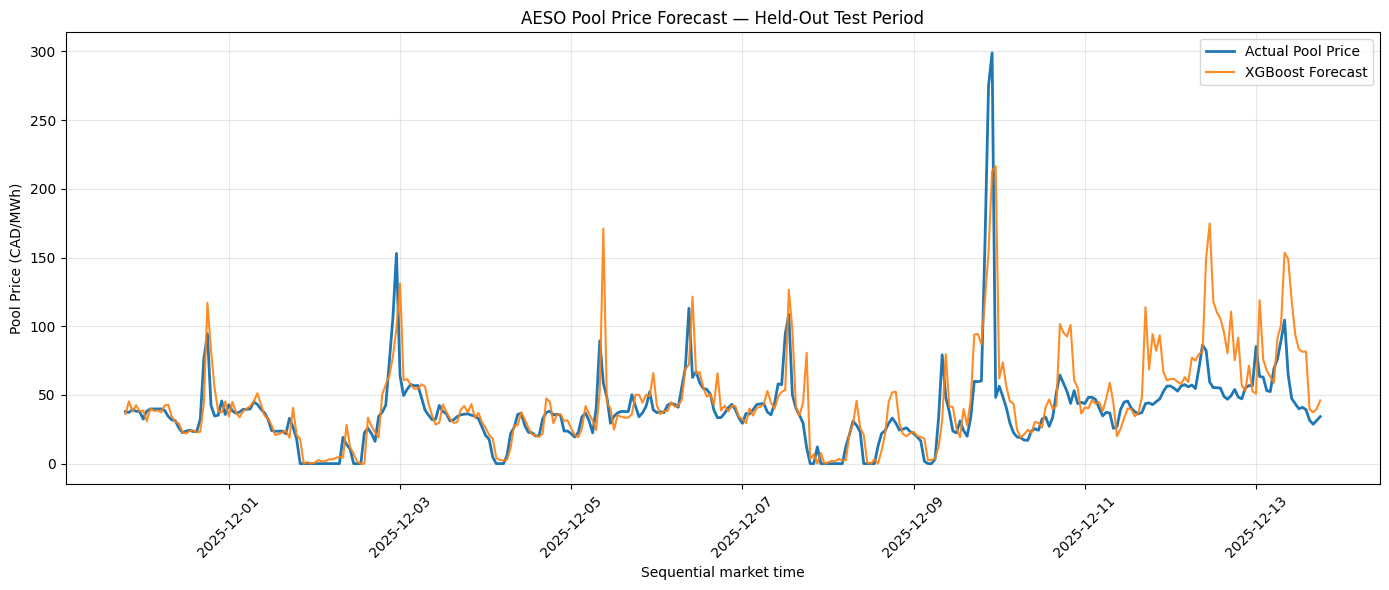

In [ ]:
n_plot = min(336, len(price_test))

plt.figure(figsize=(14, 6))
plt.plot(price_test["model_timestamp"].iloc[:n_plot], y_test_price.iloc[:n_plot],
         label="Actual Pool Price", linewidth=2)
plt.plot(price_test["model_timestamp"].iloc[:n_plot], pred_price_xgb[:n_plot],
         label="XGBoost Forecast", alpha=0.9)

plt.title("AESO Pool Price Forecast — Held-Out Test Period")
plt.xlabel("Sequential market time")
plt.ylabel("Pool Price (CAD/MWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Notes**

* The chart compares XGBoost forecasts with actual pool prices over the first two weeks of the held-out test period.

* The model generally follows normal price movements and identifies some periods of higher-price risk, but it does not consistently predict the size of sharp price spikes.

* It sometimes underestimates actual spikes and sometimes forecasts increases that do not fully occur.

* This confirms that pool price is much harder to forecast than load using historical price, demand and calendar information alone, and suggests that additional market drivers would be needed to improve extreme-price predictions.

## **Price error by price regime**

Exact-dollar errors usually become much larger during spikes. Looking at error by regime makes the limitation visible instead of hiding it inside one overall MAE.

This section asks - How accurate is XGBoost when prices are low, moderate, high, or extremely high?

In [ ]:
price_results = price_test[
    ["model_timestamp", "local_datetime_naive", "date", "hour", "dayofweek", "month", "pool_price"]
].copy()
price_results["pred_price_xgb"] = pred_price_xgb
price_results["pred_price_naive_1h"] = pred_price_naive_1h
price_results["error_xgb"] = price_results["pool_price"] - price_results["pred_price_xgb"]
price_results["abs_error_xgb"] = price_results["error_xgb"].abs()

price_results["price_regime"] = pd.cut(
    price_results["pool_price"],
    bins=[-np.inf, 50, 100, 250, np.inf],
    labels=["< $50", "$50–100", "$100–250", ">= $250"],
)

price_error_by_regime = (
    price_results.groupby("price_regime", observed=True)
    .agg(
        observations=("pool_price", "size"),
        actual_mean=("pool_price", "mean"),
        forecast_mean=("pred_price_xgb", "mean"),
        MAE=("abs_error_xgb", "mean"),
    )
    .reset_index()
)

price_error_by_regime

,price_regime,observations,actual_mean,forecast_mean,MAE
0,< $50,2878,19.256598,24.018253,7.159960
1,$50–100,304,66.441743,79.574715,28.116101
2,$100–250,75,154.578800,135.209152,85.043243
3,>= $250,36,572.040000,361.324646,250.386015


**Notes**

* The regime analysis shows that XGBoost performs well during normal low-price periods but becomes much less accurate as prices rise.

* MAE increases from about 7CAD/MWh below 50CAD to about 250CAD/MWh for prices above 250CAD.

* The model also tends to underestimate the most extreme price spikes. This shows that the overall MAE hides an important weakness: the model is much better at forecasting normal market conditions than rare, high-price events.

## **Price-model feature importance**

,feature,importance
0,price_lag_1,0.210771
1,hour_cos,0.053860
2,price_change_1h,0.049702
3,price_lag_2,0.036261
4,price_roll_max_6,0.031478
5,dayofweek,0.026094
6,hour_sin,0.025031
7,month_cos,0.023509
8,load_roll_mean_24,0.021736
9,price_roll_max_24,0.021470


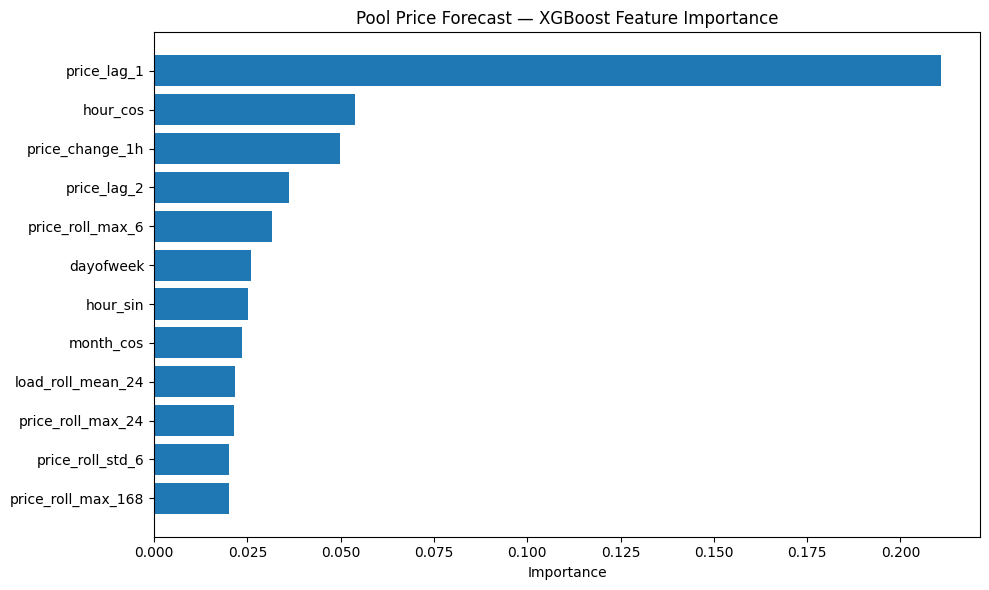

In [ ]:
price_importance = (
    pd.DataFrame({
        "feature": price_features,
        "importance": xgb_price.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(price_importance.head(15))

plt.figure(figsize=(10, 6))
top = price_importance.head(12).sort_values("importance")
plt.barh(top["feature"], top["importance"])
plt.title("Pool Price Forecast — XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Notes**

* The previous hour’s pool price is the strongest single price predictor, confirming the importance of recent market behaviour.
* Unlike the load model, no single feature dominates the price forecast. Recent price changes, volatility, previous price highs, calendar patterns, and recent load conditions all contribute.
* The model also uses a **720-hour historical rolling price window** (roughly 30 days), calculated only from prior observations.
* Overall, the feature mix reinforces that pool price is a more complex forecasting problem than load and benefits from several signals rather than one dominant lag.


# Part C — High-Price Risk Model

An exact price forecast may miss the magnitude of a rare spike while still detecting that conditions look risky. This classifier estimates the probability that price will be at or above the chosen threshold.

The default threshold is **$100/MWh**, but it is defined near the top of the notebook so you can change it.

In [ ]:
# Align classifier rows exactly with the price-regression dataset/split.
y_train_spike = (price_train["pool_price"] >= PRICE_SPIKE_THRESHOLD).astype(int)
y_test_spike = (price_test["pool_price"] >= PRICE_SPIKE_THRESHOLD).astype(int)

positive = y_train_spike.sum()
negative = len(y_train_spike) - positive
scale_pos_weight = negative / max(positive, 1)

xgb_spike = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_spike.fit(X_train_price, y_train_spike)

prob_high_price = xgb_spike.predict_proba(X_test_price)[:, 1]
pred_high_price = (prob_high_price >= 0.50).astype(int)

spike_metrics = pd.DataFrame([{
    "Threshold_CAD_per_MWh": PRICE_SPIKE_THRESHOLD,
    "Precision": precision_score(y_test_spike, pred_high_price, zero_division=0),
    "Recall": recall_score(y_test_spike, pred_high_price, zero_division=0),
    "F1": f1_score(y_test_spike, pred_high_price, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_spike, prob_high_price)
        if y_test_spike.nunique() > 1 else np.nan,
}])

spike_metrics

,Threshold_CAD_per_MWh,Precision,Recall,F1,ROC_AUC
0,100.0,0.565574,0.616071,0.589744,0.962436


In [ ]:
price_results["actual_high_price"] = y_test_spike.values
price_results["prob_high_price"] = prob_high_price
price_results["pred_high_price"] = pred_high_price

# Highest-risk forecast hours in the held-out period.
price_results.nlargest(
    15, "prob_high_price"
)[[
    "date", "hour", "pool_price", "pred_price_xgb",
    "prob_high_price", "actual_high_price"
]]

,date,hour,pool_price,pred_price_xgb,prob_high_price,actual_high_price
14773,2026-01-05,12,845.76,750.638794,0.997650,1
14772,2026-01-05,11,858.44,744.585938,0.996757,1
14774,2026-01-05,13,712.95,714.547852,0.994636,1
14779,2026-01-05,18,657.70,672.419373,0.993309,1
16700,2026-03-26,20,948.63,374.792786,0.992891,1
16701,2026-03-26,21,274.39,511.598175,0.992417,1
16293,2026-03-09,21,103.04,394.944122,0.991035,1
14777,2026-01-05,16,618.34,633.865295,0.989380,1
14706,2026-01-02,17,286.30,353.011780,0.987337,1
14778,2026-01-05,17,695.34,642.125061,0.985981,1


# Part D — What the two forecasting problems tell us

The most important comparison is not simply “which model has the highest R²?”

- **Load:** repeated human and industrial schedules plus strong autocorrelation make demand comparatively stable and forecastable.
- **Price:** recent price/load history helps, but price formation depends on additional supply-side and system variables absent from this dataset.
- **Practical implication:** model complexity can improve both problems, but better **features and market information** matter more than simply choosing a more complex algorithm.

In [ ]:
summary_metrics = pd.concat([
    load_metrics.assign(Target="Load"),
    price_metrics.assign(Target="Pool Price"),
], ignore_index=True)

summary_metrics = summary_metrics[["Target", "Model", "MAE", "RMSE", "R2"]]
summary_metrics

,Target,Model,MAE,RMSE,R2
0,Load,Linear Regression,60.417053,79.862594,0.983005
1,Load,XGBoost,54.931961,85.120385,0.980693
2,Pool Price,Naive: previous hour,11.621722,47.131917,0.509364
3,Pool Price,Naive: same hour yesterday,31.036137,87.382900,-0.686485
4,Pool Price,XGBoost,13.527422,42.342609,0.604010


# **Part E — Prepare the Streamlit portfolio dashboard**

The original project used a load-only Streamlit dashboard. This final version expands it into one viewer-friendly app covering **load, pool price, high-price risk, and model interpretation**.

The dashboard is written for both technical and casual viewers. Raw feature names are translated into plain-language labels, and a collapsible **How to read this dashboard** section defines the main electricity-market and machine-learning terms.

In [ ]:
dashboard_df = pd.merge(
    load_results[["model_timestamp", "local_datetime_naive", "load", "pred_load_xgb", "abs_error_xgb"]].rename(columns={"abs_error_xgb":"load_abs_error"}),
    price_results[["model_timestamp", "pool_price", "pred_price_xgb", "prob_high_price", "actual_high_price", "abs_error_xgb"]].rename(columns={"abs_error_xgb":"price_abs_error"}),
    on="model_timestamp", how="inner")
print("Dashboard rows:", len(dashboard_df))
dashboard_df.head()

## **Viewer-friendly feature names**

The models keep their technical feature names internally, while the dashboard uses a display-name dictionary. For example, `load_lag_24` becomes **Load — Same Hour Yesterday** and `price_roll_max_24` becomes **Highest Price — Previous 24 Hours**. This changes presentation only, not the models.

In [ ]:
FEATURE_DISPLAY_NAMES = {
"load_lag_1":"Load — Previous Hour", "load_lag_2":"Load — Two Hours Ago", "load_lag_24":"Load — Same Hour Yesterday", "load_lag_48":"Load — Same Hour Two Days Ago", "load_lag_168":"Load — Same Hour Last Week",
"load_roll_mean_6":"Average Load — Previous 6 Hours", "load_roll_std_6":"Load Variability — Previous 6 Hours", "load_roll_mean_24":"Average Load — Previous 24 Hours", "load_roll_std_24":"Load Variability — Previous 24 Hours", "load_roll_mean_168":"Average Load — Previous Week", "load_roll_std_168":"Load Variability — Previous Week", "load_change_1h":"Recent Load Change",
"price_lag_1":"Price — Previous Hour", "price_lag_2":"Price — Two Hours Ago", "price_lag_3":"Price — Three Hours Ago", "price_lag_24":"Price — Same Hour Yesterday", "price_lag_48":"Price — Same Hour Two Days Ago", "price_lag_168":"Price — Same Hour Last Week",
"price_roll_mean_6":"Average Price — Previous 6 Hours", "price_roll_std_6":"Price Variability — Previous 6 Hours", "price_roll_max_6":"Highest Price — Previous 6 Hours", "price_roll_mean_24":"Average Price — Previous 24 Hours", "price_roll_std_24":"Price Variability — Previous 24 Hours", "price_roll_max_24":"Highest Price — Previous 24 Hours", "price_roll_mean_168":"Average Price — Previous Week", "price_roll_std_168":"Price Variability — Previous Week", "price_roll_max_168":"Highest Price — Previous Week", "price_roll_mean_720":"Average Price — Previous 30 Days", "price_roll_std_720":"Price Variability — Previous 30 Days", "price_roll_max_720":"Highest Price — Previous 30 Days", "price_change_1h":"Recent Price Change",
"hour":"Hour of Day", "dayofweek":"Day of Week", "month":"Month", "day":"Day of Month", "is_weekend":"Weekend Indicator", "hour_sin":"Time of Day Pattern (sin)", "hour_cos":"Time of Day Pattern (cos)", "dow_sin":"Weekly Pattern (sin)", "dow_cos":"Weekly Pattern (cos)", "month_sin":"Seasonal Pattern (sin)", "month_cos":"Seasonal Pattern (cos)"}
load_importance_display = load_importance.copy(); load_importance_display["display_feature"] = load_importance_display["feature"].map(FEATURE_DISPLAY_NAMES).fillna(load_importance_display["feature"])
price_importance_display = price_importance.copy(); price_importance_display["display_feature"] = price_importance_display["feature"].map(FEATURE_DISPLAY_NAMES).fillna(price_importance_display["feature"])
display(load_importance_display.head(10)); display(price_importance_display.head(10))

# **Part F — Export dashboard-ready data**

The public Streamlit app reads precomputed model outputs instead of retraining whenever a visitor opens the page. This keeps the app fast and separates model development from presentation.

In [ ]:
OUTPUT_DIR = Path("aeso_final_outputs"); OUTPUT_DIR.mkdir(exist_ok=True)
load_results.to_csv(OUTPUT_DIR / "load_forecast_results.csv", index=False)
price_results.to_csv(OUTPUT_DIR / "price_forecast_results.csv", index=False)
dashboard_df.to_csv(OUTPUT_DIR / "dashboard_data.csv", index=False)
load_metrics.to_csv(OUTPUT_DIR / "load_model_metrics.csv", index=False)
price_metrics.to_csv(OUTPUT_DIR / "price_model_metrics.csv", index=False)
spike_metrics.to_csv(OUTPUT_DIR / "high_price_classifier_metrics.csv", index=False)
load_importance_display.to_csv(OUTPUT_DIR / "load_feature_importance.csv", index=False)
price_importance_display.to_csv(OUTPUT_DIR / "price_feature_importance.csv", index=False)
price_error_by_regime.to_csv(OUTPUT_DIR / "price_error_by_regime.csv", index=False)
print("Dashboard files written to:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.glob("*.csv")): print(" -", p.name)

# **Part G — Generate the Streamlit app**

The next cell writes a complete `app.py` with five tabs: **Overview, Load Forecast, Pool Price, High-Price Risk, and Model Insights**. It includes viewer-friendly feature names, a glossary, explanatory notes, and an explicit warning that the charts show held-out historical test results rather than live forecasts.

In [ ]:
APP_CODE = 'import streamlit as st\nfrom pathlib import Path\nimport pandas as pd\nimport plotly.express as px\nimport plotly.graph_objects as go\n\nst.set_page_config(page_title="AESO Load & Pool Price Forecasting", page_icon="⚡", layout="wide")\n\nBASE_DIR = Path(__file__).resolve().parent\nDATA_DIR = BASE_DIR / "aeso_final_outputs"\nif not DATA_DIR.exists():\n    DATA_DIR = BASE_DIR\n\n@st.cache_data\ndef load_data():\n    files = {\n        "dashboard": "dashboard_data.csv",\n        "load_metrics": "load_model_metrics.csv",\n        "price_metrics": "price_model_metrics.csv",\n        "spike_metrics": "high_price_classifier_metrics.csv",\n        "load_importance": "load_feature_importance.csv",\n        "price_importance": "price_feature_importance.csv",\n        "price_regime": "price_error_by_regime.csv",\n    }\n    data, missing = {}, []\n    for key, filename in files.items():\n        path = DATA_DIR / filename\n        if path.exists(): data[key] = pd.read_csv(path)\n        else: missing.append(filename)\n    if missing:\n        st.error("Missing dashboard files: " + ", ".join(missing)); st.stop()\n    data["dashboard"]["local_datetime_naive"] = pd.to_datetime(data["dashboard"]["local_datetime_naive"], errors="coerce")\n    return data\n\ndata = load_data()\ndashboard = data["dashboard"].sort_values("local_datetime_naive").copy()\nload_metrics, price_metrics = data["load_metrics"], data["price_metrics"]\nspike_metrics, price_regime = data["spike_metrics"], data["price_regime"]\nload_importance, price_importance = data["load_importance"], data["price_importance"]\n\nst.title("⚡ AESO Short-Term Load & Pool Price Forecasting")\nst.caption("Alberta hourly market data | leakage-safe time-series features | Linear Regression + XGBoost")\nst.markdown("""\nThis project asks two related questions: **how predictable is Alberta electricity demand, and how predictable is the hourly pool price using historical market information?** The results show a clear contrast: load follows strong recurring patterns, while price becomes much harder to forecast during volatile market conditions.\n""")\n\nwith st.expander("📖 How to read this dashboard"):\n    st.markdown("""\n**AIL (Alberta Internal Load)** — electricity demand within Alberta, measured in megawatts (MW).\n\n**Pool Price ($/MWh)** — Alberta\'s hourly wholesale electricity price in Canadian dollars per megawatt-hour.\n\n**MAE (Mean Absolute Error)** — the average size of a forecast error. Lower is better.\n\n**RMSE (Root Mean Squared Error)** — similar to MAE, but gives larger errors more weight. Lower is better.\n\n**R²** — measures how much variation in observed values is explained by the model. Values closer to 1 indicate a stronger fit on the test data.\n\n**ROC-AUC** — measures how well the high-price classifier ranks high-price hours above normal-price hours across probability thresholds. Values closer to 1 indicate stronger discrimination.\n\n**High-Price Probability** — the estimated probability that pool price is at least **$100/MWh**, the threshold used in this project.\n\n**Lag Feature** — a past observation used to predict a future observation. *Load — Same Hour Yesterday* uses load 24 hours earlier.\n\n**Feature Importance** — an XGBoost measure of how much each input contributed to model decisions. It is not proof of causation.\n""")\n\nload_xgb = load_metrics.loc[load_metrics["Model"] == "XGBoost"].iloc[0]\nprice_xgb = price_metrics.loc[price_metrics["Model"] == "XGBoost"].iloc[0]\nprice_naive = price_metrics.loc[price_metrics["Model"] == "Naive: previous hour"].iloc[0]\nspike = spike_metrics.iloc[0]\nauc_col = "ROC_AUC" if "ROC_AUC" in spike.index else "ROC-AUC"\n\ndays_available = max(1, int((dashboard["local_datetime_naive"].max() - dashboard["local_datetime_naive"].min()).days) + 1)\nwindow_days = st.sidebar.selectbox("Detailed chart window", [7, 14, 30, 60], index=1, help="Most recent days of the held-out test period.")\nwindow_days = min(window_days, days_available)\nwindow = dashboard.tail(min(24 * window_days, len(dashboard))).copy()\n\noverview_tab, load_tab, price_tab, risk_tab, insights_tab = st.tabs(["Overview", "Load Forecast", "Pool Price", "High-Price Risk", "Model Insights"])\n\nwith overview_tab:\n    c1, c2, c3, c4 = st.columns(4)\n    c1.metric("Load MAE", f"{load_xgb[\'MAE\']:.1f} MW")\n    c2.metric("Load R²", f"{load_xgb[\'R2\']:.3f}")\n    c3.metric("Price MAE", f"${price_xgb[\'MAE\']:.2f}/MWh")\n    c4.metric("High-Price ROC-AUC", f"{spike[auc_col]:.3f}")\n    st.subheader("What stood out")\n    st.markdown(f"""\n- **Load was highly predictable:** XGBoost achieved an R² of **{load_xgb[\'R2\']:.3f}** with an MAE of **{load_xgb[\'MAE\']:.1f} MW**.\n- **Price was more difficult:** XGBoost explained more price variation than the previous-hour baseline, but its typical absolute error was **${price_xgb[\'MAE\']:.2f}/MWh** versus **${price_naive[\'MAE\']:.2f}/MWh** for the simple previous-hour forecast.\n- **Extreme prices were the hardest problem:** overall price metrics hide much larger errors during high-price periods.\n- **Reframing helped:** the high-price classifier provides a probability signal even when exact spike magnitude is difficult to predict.\n""")\n    st.info("Held-out historical test performance — not a live AESO price or demand forecast.")\n\nwith load_tab:\n    st.subheader(f"Actual vs forecast Alberta Internal Load — last {window_days} days shown")\n    fig = go.Figure()\n    fig.add_trace(go.Scatter(x=window["local_datetime_naive"], y=window["load"], name="Actual Load", mode="lines"))\n    fig.add_trace(go.Scatter(x=window["local_datetime_naive"], y=window["pred_load_xgb"], name="XGBoost Forecast", mode="lines"))\n    fig.update_layout(xaxis_title="Alberta local time", yaxis_title="Load (MW)", hovermode="x unified", legend_title_text="")\n    st.plotly_chart(fig, use_container_width=True)\n    st.markdown("**How to interpret it:** load follows strong hourly and daily patterns, so the forecast usually tracks the actual series closely. Larger misses can point to missing drivers such as unusual weather, holidays, or operational changes.")\n    st.dataframe(load_metrics, use_container_width=True, hide_index=True)\n\nwith price_tab:\n    st.subheader(f"Actual vs forecast pool price — last {window_days} days shown")\n    fig = go.Figure()\n    fig.add_trace(go.Scatter(x=window["local_datetime_naive"], y=window["pool_price"], name="Actual Pool Price", mode="lines"))\n    fig.add_trace(go.Scatter(x=window["local_datetime_naive"], y=window["pred_price_xgb"], name="XGBoost Forecast", mode="lines"))\n    fig.update_layout(xaxis_title="Alberta local time", yaxis_title="Pool Price (CAD/MWh)", hovermode="x unified", legend_title_text="")\n    st.plotly_chart(fig, use_container_width=True)\n    st.markdown("**How to interpret it:** the model follows many normal price movements but is less reliable at predicting the size of sharp price spikes, where omitted supply-side information matters more.")\n    st.subheader("Forecast error by actual price regime")\n    mae_candidates = [c for c in price_regime.columns if "mae" in c.lower()]\n    regime_col = "price_regime" if "price_regime" in price_regime.columns else price_regime.columns[0]\n    if mae_candidates:\n        mae_col = mae_candidates[0]\n        fig_regime = px.bar(price_regime, x=regime_col, y=mae_col, labels={regime_col:"Actual Pool Price Range", mae_col:"MAE (CAD/MWh)"})\n        st.plotly_chart(fig_regime, use_container_width=True)\n    else:\n        st.dataframe(price_regime, use_container_width=True, hide_index=True)\n    st.dataframe(price_metrics, use_container_width=True, hide_index=True)\n\nwith risk_tab:\n    st.subheader("High-price probability")\n    fig = go.Figure()\n    fig.add_trace(go.Scatter(x=window["local_datetime_naive"], y=window["pool_price"], name="Actual Pool Price", mode="lines", yaxis="y1"))\n    fig.add_trace(go.Scatter(x=window["local_datetime_naive"], y=window["prob_high_price"], name="High-Price Probability", mode="lines", yaxis="y2"))\n    fig.update_layout(xaxis_title="Alberta local time", yaxis=dict(title="Pool Price (CAD/MWh)"), yaxis2=dict(title="Probability", overlaying="y", side="right", range=[0,1]), hovermode="x unified", legend_title_text="")\n    st.plotly_chart(fig, use_container_width=True)\n    st.markdown("The exact price forecast may miss spike magnitude while the classifier can still recognize conditions resembling previous high-price periods. Price forecasting and high-price risk detection are therefore treated as related but different questions.")\n    st.dataframe(spike_metrics, use_container_width=True, hide_index=True)\n\nwith insights_tab:\n    st.subheader("What drives the load model?")\n    top_load = load_importance.nlargest(12, "importance").sort_values("importance")\n    label_col = "display_feature" if "display_feature" in top_load.columns else "feature"\n    st.plotly_chart(px.bar(top_load, x="importance", y=label_col, orientation="h", labels={"importance":"XGBoost Importance", label_col:"Feature"}), use_container_width=True)\n    st.caption("Feature importance shows what the model relied on, not necessarily a causal relationship.")\n    st.subheader("What drives the price model?")\n    top_price = price_importance.nlargest(12, "importance").sort_values("importance")\n    label_col = "display_feature" if "display_feature" in top_price.columns else "feature"\n    st.plotly_chart(px.bar(top_price, x="importance", y=label_col, orientation="h", labels={"importance":"XGBoost Importance", label_col:"Feature"}), use_container_width=True)\n    with st.expander("Methodology and project evolution"):\n        st.markdown("""\n**Forecast design:** chronological train/test split; only information available before the forecast hour; rolling features shifted by one hour; realized same-hour target variables excluded from the opposite model.\n\n**Why this differs from the original load-only project:** this final version revisits the feature engineering, makes information timing more explicit, expands into pool-price forecasting, adds simple baselines, and adds high-price risk classification.\n\n**What is still missing:** historical load, price, and calendar information cannot fully describe market conditions. Weather, generation mix, wind/solar output and forecasts, outages, imports/exports, and available capability are logical additions for a production-oriented price model.\n""")\n\nst.divider()\nst.caption("Portfolio project using historical AESO hourly market data. Outputs shown are held-out historical test results, not operational forecasts.")\n'

app_path = OUTPUT_DIR / 'app.py'
app_path.write_text(APP_CODE, encoding='utf-8')
print('Created:', app_path)


## **Create `requirements.txt` for Streamlit Community Cloud**

Because the deployed app only reads exported CSVs, it needs Streamlit, pandas, and Plotly but does not need to retrain XGBoost in the public app.

In [ ]:
requirements = "streamlit>=1.40\npandas>=2.0\nplotly>=5.20\n"
requirements_path = OUTPUT_DIR / "requirements.txt"
requirements_path.write_text(requirements, encoding="utf-8")
print("Created:", requirements_path)

# **Part H — Deployment check**

Test locally with `streamlit run app.py`. For Streamlit Community Cloud, put `app.py`, `requirements.txt`, and the exported CSVs in the same GitHub repository (either at the root or inside `aeso_final_outputs/`). Before publishing, confirm the metrics match the notebook, the $100/MWh risk threshold is clearly stated, and the app is labelled as a historical held-out test rather than a live forecast.

# **Part I — What this project demonstrates**

This final version demonstrates time-series cleaning and DST handling, leakage-safe feature engineering, chronological validation, simple baselines, Linear Regression and XGBoost regression, high-price classification, error analysis, model interpretation, and communication of technical results to a non-technical audience.

The main lesson is broader than AESO: **model complexity cannot replace missing information or domain understanding.** Load is strongly structured and relatively forecastable from its own history. Pool price responds to a wider set of market conditions, so historical price/load patterns are useful but incomplete.

For a future petroleum-engineering project, the same workflow can be carried forward: establish simple engineering baselines, use realistic validation, add machine learning only where it provides measurable value, and interpret outputs using physical and commercial context.

## **Optional next-step features if the AESO project were extended**

This portfolio project is intentionally being closed at this stage. A more production-oriented electricity-market model could add weather forecasts, generation by fuel type, wind/solar output, outages, imports/exports, available capability, holiday flags, and walk-forward validation. These are documented as limitations and future possibilities rather than required work for this version.

# **Part J — Copy final portfolio files to Google Drive (optional in Colab)**

In [ ]:
import shutil
source_dir = Path("aeso_final_outputs")
drive_output_dir = Path("/content/drive/MyDrive/Private projects/AESO Data/output")
if Path("/content/drive").exists():
    drive_output_dir.mkdir(parents=True, exist_ok=True)
    for file in source_dir.iterdir():
        if file.is_file(): shutil.copy2(file, drive_output_dir / file.name)
    print("Copied final portfolio files to:", drive_output_dir)
    for file in sorted(drive_output_dir.iterdir()): print(" -", file.name)
else:
    print("Google Drive is not mounted. Files remain in:", source_dir.resolve())